<a href="https://colab.research.google.com/github/crossbone72/AI-Class/blob/main/weak6/DL_abalone_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/Colab Notebooks/abalone.csv'
df = pd.read_csv(path)
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [2]:
y=df['Rings']
y.value_counts()
y

,Rings
0,15
1,7
2,9
3,10
4,7
...,...
4172,11
4173,10
4174,9
4175,10


In [3]:
X=df.drop(['Rings', 'id'],axis=1)
X = pd.get_dummies(X, columns=['Sex'], drop_first=True, dtype=float)
X

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,0.0,1.0
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,0.0,1.0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,0.0,0.0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,0.0,1.0
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,1.0,0.0
...,...,...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,0.0,0.0
4173,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,0.0,1.0
4174,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,0.0,1.0
4175,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,0.0,0.0


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=0)

In [5]:
#스케일링 추가
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
#분할된 학습 및 테스트 데이터셋의 크기(shape) 확인
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3341, 9), (3341,), (836, 9), (836,))

In [7]:
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

#3개의 은닉층을 가진 심층 신경망(DNN) 회귀 모델 설계
model = Sequential()

model.add(Dense(128,input_shape=(9,),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1))

#모델 컴파일 설정 - 손실함수(mse)와 평가지표, 최적화 알고리즘(rmsprop)을 설정하여 학습 준비
model.compile(optimizer = 'rmsprop', loss = 'mse', metrics = ['mse'])

#모델 요약 정보 출력 - 생성된 신경망의 전체 구조, 층별 출력 형태, 학습 가능한 파라미터 수 확인
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#모델 학습 실행 - 학습 데이터(train)를 이용해 최적의 가중치를 찾고, 테스트 데이터(test)로 매 에포크마다 성능 검증
N_EPOCHS = 50

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
#학습된 모델을 이용한 예측 - 테스트 데이터셋(X_test)을 입력하여 모델이 예측한 결과값을 산출
y_pred = model.predict(X_test)

Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 26.5708 - mse: 26.5708 - val_loss: 6.1156 - val_mse: 6.1156
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 6.7951 - mse: 6.7951 - val_loss: 5.2197 - val_mse: 5.2197
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.0679 - mse: 6.0679 - val_loss: 5.0162 - val_mse: 5.0162
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.5010 - mse: 5.5010 - val_loss: 4.7564 - val_mse: 4.7564
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 5.4627 - mse: 5.4627 - val_loss: 5.0442 - val_mse: 5.0442
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.1561 - mse: 5.1561 - val_loss: 4.7903 - val_mse: 4.7903
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.9943 - mse: 4.9943 - val_loss: 4.7182 - val_mse: 4.7182
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.7598 - mse: 4.7598 - val_loss: 5.0211 - val_mse: 5.0211
Epoch 9/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step

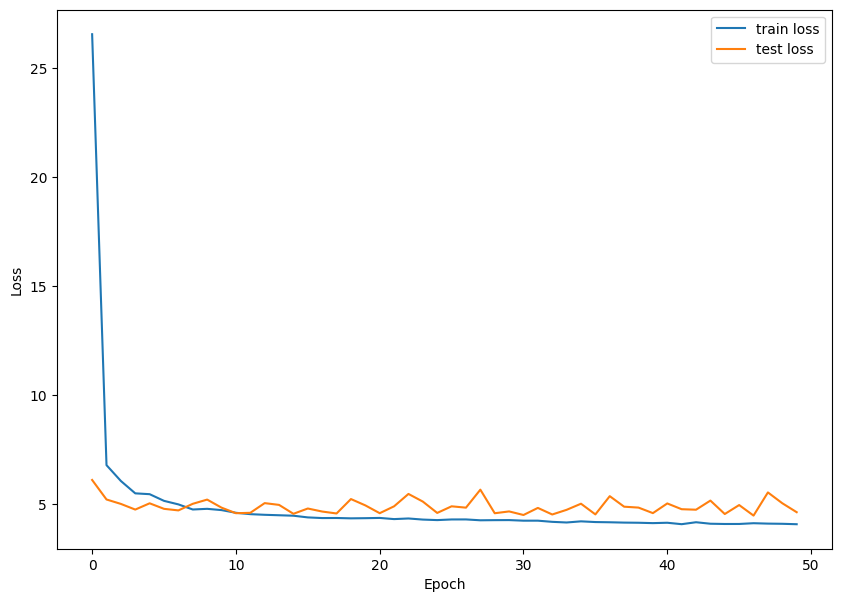

In [9]:
#학습 과정의 손실(loss) 변화 시각화 - 학습 데이터와 검증 데이터의 오차 추이 비교
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [10]:
#최종 모델 평가 - 테스트 데이터를 사용하여 모델의 손실(loss)과 평가지표 확인
model.evaluate(X_test, y_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.6361 - mse: 4.6361


[4.636102676391602, 4.636102676391602]